### ***Data Wrangling*** ###

In [58]:
import pandas as pd
import numpy as np

In [59]:
# read the data for analysis
dataframe=pd.read_csv(r'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_1.csv')
if dataframe is not None :
    print('Data read successfully')
else :
    print('Failed to read data')

Data read successfully


In [60]:
# calculate percent of null values
dataframe.isnull().sum()/len(dataframe)*100

FlightNumber       0.000000
Date               0.000000
BoosterVersion     0.000000
PayloadMass        0.000000
Orbit              0.000000
LaunchSite         0.000000
Outcome            0.000000
Flights            0.000000
GridFins           0.000000
Reused             0.000000
Legs               0.000000
LandingPad        28.888889
Block              0.000000
ReusedCount        0.000000
Serial             0.000000
Longitude          0.000000
Latitude           0.000000
dtype: float64

In [61]:
# numerical or categorical values
cat_cols=dataframe.select_dtypes(include=['object']).columns.to_list()
num_cols=dataframe.select_dtypes(include=['number']).columns.to_list()

In [62]:
# calculate the number of launches in each site
launches=dataframe['LaunchSite'].value_counts().reset_index()

In [63]:
launches

,LaunchSite,count
0,CCAFS SLC 40,55
1,KSC LC 39A,22
2,VAFB SLC 4E,13


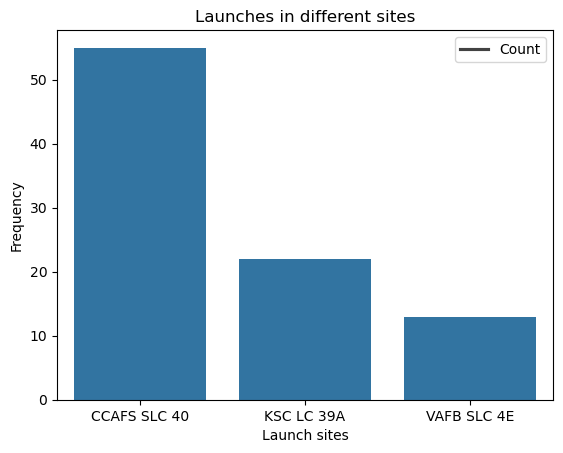

In [64]:
# lets plot a bar 
import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot(data=launches,x='LaunchSite',y='count')
plt.title('Launches in different sites')
plt.xlabel('Launch sites')
plt.ylabel('Frequency')
plt.legend(['Count'])
plt.show()

In [65]:
# number of occurence of each orbit
occurence=dataframe['Orbit'].value_counts().reset_index()

In [76]:
occurence

,Orbit,count
0,GTO,27
1,ISS,21
2,VLEO,14
3,PO,9
4,LEO,7
5,SSO,5
6,MEO,3
7,ES-L1,1
8,HEO,1
9,SO,1


In [66]:
# occurence of each orbit
import plotly.express as px
px.bar(occurence,x='Orbit',y='count',color='Orbit',title='Occurence of each orbit',hover_data='count')

In [67]:
# landing outcomes
outcomes=dataframe['Outcome'].value_counts().reset_index()

In [68]:
# outcome results
px.bar(outcomes,x='Outcome',y='count',color='Outcome',hover_data='count',title='Outcomes of landing')

In [69]:
# good outcomes 
good_outcomes=['True Ocean','True RTLS','True ASDS']
bad_outcomes=['False Ocean','False RTLS','False ASDS','None ASDS','None None']

In [70]:
# function to handle 0 and 1
def handle(val):
    if val in good_outcomes:
        return 1
    else :
        return 0

In [71]:
# label outcome column
dataframe['landing_outcomes']=dataframe['Outcome'].apply(handle)

In [72]:
# added successfully
dataframe['Class']=dataframe['landing_outcomes']

In [77]:
dataframe['Class'].value_counts()

Class
1    60
0    30
Name: count, dtype: int64

In [73]:
# determine succes rate
round(dataframe['Class'].mean()*100,2)

66.67

In [75]:
# lets save data set
dataframe.drop(columns=
{'landing_outcomes'},inplace=True)
dataframe.to_csv('dataeet_wrangled.csv',index=False)